# Maryland Housing Review
Theophilus Braimoh

5-13-2026

Python notebook analyzing Maryland Housing Rehab Program loans and the state's population density. 

In [1]:
#import necessary packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

popden = pd.read_csv("Cleaned Data/[CLEANED] Maryland_Resident_Population_Per_Square_Mile__2010-2024.csv")
awards = pd.read_csv("Cleaned Data/[CLEANED] Maryland_Housing_Rehab_Special_Loans_Program_FY_2011-2023.csv")

In [2]:
# Data Cleaning
for year in popden["Fiscal Year"]:
    year = "2010"

popden["Fiscal Year"] = [str(year)[-4:] for year in popden["Fiscal Year"]]

del popden['Reporting period start date']
del popden['Reporting period end data']
del popden['Date created']


In [3]:
print(popden.head(5))
print(f"\nThe length of popden is: {len(popden)}")

           County  Population density per square mile Fiscal Year
0        Maryland                               594.8        2010
1        Allegany                               176.9        2010
2    Anne Arundel                              1295.8        2010
3  Baltimore City                              7669.2        2010
4       Baltimore                              1346.0        2010

The length of popden is: 400


In [4]:
# Filter out entries that say "Maryland"
temp = [county for county in popden["County"] if county != "Maryland"]

popden = popden[popden["County"].isin(temp)]

In [5]:
print(popden.head(5))

print("\n")
      
print(f"The length of popden is: {len(popden)}")

           County  Population density per square mile Fiscal Year
1        Allegany                               176.9        2010
2    Anne Arundel                              1295.8        2010
3  Baltimore City                              7669.2        2010
4       Baltimore                              1346.0        2010
5         Calvert                               416.3        2010


The length of popden is: 384


In [6]:
county_names = popden['County'].unique()
print(county_names)
print(len(county_names))

['Allegany' 'Anne Arundel' 'Baltimore City' 'Baltimore' 'Calvert'
 'Caroline' 'Carroll' 'Cecil' 'Charles' 'Dorchester' 'Frederick' 'Garrett'
 'Harford' 'Howard' 'Kent' 'Montgomery' "Prince George's" "Queen Anne's"
 "Saint Mary's" 'Somerset' 'Talbot' 'Washington' 'Wicomico' 'Worcester']
24


In [7]:
print(popden.keys())

Index(['County', 'Population density per square mile', 'Fiscal Year'], dtype='object')


In [8]:
# Change key column name for population density
popden.rename(columns = {"Population density per square mile": "Pop_Density"}, inplace=True)

column_names = ["County", "Fiscal Year", "Pop_Density"]

popden.set_index(column_names[:2], inplace=True)

popden.sort_index(inplace=True)


In [9]:
popden.head(5)

Pop_Density
County   Fiscal Year             
Allegany 2010               176.9
         2011               176.6
         2012               175.2
         2013               173.3
         2014               171.9

In [10]:
popden.head(5)

Pop_Density
County   Fiscal Year             
Allegany 2010               176.9
         2011               176.6
         2012               175.2
         2013               173.3
         2014               171.9

In [11]:
popden.loc['Allegany'].head(5)

,Pop_Density
Fiscal Year,
2010,176.9
2011,176.6
2012,175.2
2013,173.3
2014,171.9


In [12]:
# variable for index-slicing
idx = pd.IndexSlice


#Reindex Pop Den Dataframe

#Create list for place 0 and 1 for reindexing
index1 = [int(x[1]) for x in popden.index] # cast year to int
index0 = (x[0] for x in popden.index)

#List is a zipped list of lists
int_keys = list(zip(*(index0,index1)))

# int_keys
popden.index = pd.MultiIndex.from_tuples(int_keys, names=['County', 'Fiscal Year'])
popden.reindex(index = int_keys)

print(popden.tail(5))

                       Pop_Density
County    Fiscal Year             
Worcester 2021               112.2
          2022               114.1
          2023               115.3
          2024               115.8
          2025               116.0


In [13]:
awards.head(5)

,County,Fiscal Year,Award Amount,Loans Issued
0,Allegany,2023,587783,16
1,Anne Arundel,2023,1146668,60
2,Baltimore City,2023,6374718,363
3,Baltimore,2023,2179493,161
4,Calvert,2023,201922,19


In [14]:
#get counties available in awards
print(awards['County'].unique())

print(f"\nLength of awards data frame is: {len(awards)}")

['Allegany' 'Anne Arundel' 'Baltimore City' 'Baltimore' 'Calvert'
 'Caroline' 'Carroll' 'Cecil' 'Charles' 'Dorchester' 'Frederick' 'Garrett'
 'Harford' 'Howard' 'Kent' 'Montgomery' "Prince George's" "Queen Anne's"
 "Saint Mary's" 'Somerset' 'Talbot' 'Washington' 'Wicomico' 'Worcester'
 'Multiple']

Length of awards data frame is: 290


Data cleaning for awards dataframe

In [21]:
award_clean = awards[awards['County'] != 'Multiple']

#get counties available in awards - post cleaning
print(f"Counties in awards dataframe: \n{award_clean['County'].unique()}")

print(f"\nCounties in awards dataframe: \n{len(award_clean['County'].unique())}")
#confirm new length
print(f"\nLength of awards dataframe: {len(award_clean)}")

print(f"\n{award_clean.head(5)}")

print(f"\nObject type of awards dataframe: {type(award_clean)}")


Counties in awards dataframe: 
['Allegany' 'Anne Arundel' 'Baltimore City' 'Baltimore' 'Calvert'
 'Caroline' 'Carroll' 'Cecil' 'Charles' 'Dorchester' 'Frederick' 'Garrett'
 'Harford' 'Howard' 'Kent' 'Montgomery' "Prince George's" "Queen Anne's"
 "Saint Mary's" 'Somerset' 'Talbot' 'Washington' 'Wicomico' 'Worcester']

Counties in awards dataframe: 
24

Length of awards dataframe: 287

           County  Fiscal Year  Award Amount  Loans Issued
0        Allegany         2023        587783            16
1    Anne Arundel         2023       1146668            60
2  Baltimore City         2023       6374718           363
3       Baltimore         2023       2179493           161
4         Calvert         2023        201922            19

Object type of awards dataframe: <class 'pandas.core.frame.DataFrame'>


In [16]:
award_clean_multi = award_clean.set_index(['County','Fiscal Year'])

print(award_clean_multi.head(5))

#Confirm new index comprised of County and Fiscal Year
print(f'\nIndex names: {award_clean_multi.index.names}')

                            Award Amount  Loans Issued
County         Fiscal Year                            
Allegany       2023               587783            16
Anne Arundel   2023              1146668            60
Baltimore City 2023              6374718           363
Baltimore      2023              2179493           161
Calvert        2023               201922            19

Index names: ['County', 'Fiscal Year']


Create dataframe with combined clean data

In [17]:
big_data = popden.merge(award_clean_multi,on=award_clean_multi.index.names)

big_data.head(5)

Pop_Density  Award Amount  Loans Issued
County   Fiscal Year                                         
Allegany 2011               176.6        123299             7
         2012               175.2        148323             4
         2013               173.3         24413             1
         2014               171.9        164419             5
         2016               168.3        102091             6

Intuitively, an increase in population density correlated moderately with the award amount a county received

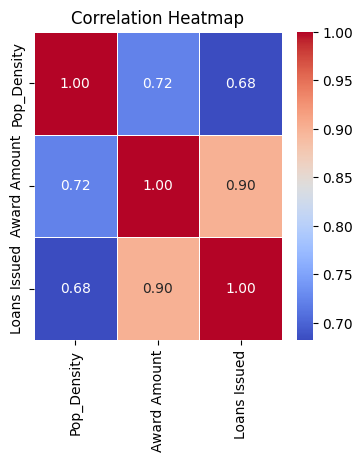

In [18]:
# Create correlation matrix heatmap

big_corr = big_data.corr()

plt.figure(figsize=(4,4))
sns.heatmap(big_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In 2023, the following counties had a relatively large spike in awards granted from the preceding year: 

Baltimore, Baltimore City, Charles, Montgomery, Prince George's, Saint Mary's and Worcester


In [19]:
sub_count = big_data.loc[idx[['Baltimore', 'Baltimore City', 'Charles',
                  'Montgomery', 'Prince George\'s', 'Saint Mary\'s','Worcester'], 2023], 'Award Amount']

sub_count

County           Fiscal Year
Baltimore        2023           2179493
Baltimore City   2023           6374718
Charles          2023            909869
Montgomery       2023            587904
Prince George's  2023           4401579
Saint Mary's     2023            598982
Worcester        2023            649296
Name: Award Amount, dtype: int64

In [20]:
print(f"In 2023, the total amount invested in these 7 counties was: ${sub_count.sum():,d}")

In 2023, the total amount invested in these 7 counties was: $15,701,841
